# HW1 Part II KID Colab Runner

This notebook is a thin GPU runner for Q4c. It embeds the current homework code zip, unpacks it inside Colab, and runs `scripts/evaluate_kid.py`.

You only need to make the trained checkpoint visible to the Colab runtime. The default path is `/content/ddpm_final.pt`.

Expected final outputs:

- `kernel_inception_distance_mean`
- `kernel_inception_distance_std`
- `/content/kid_eval/kid_metrics.json`


In [1]:
# Configuration. Edit CHECKPOINT_PATH only if your checkpoint is not at /content/ddpm_final.pt.
from pathlib import Path

CHECKPOINT_PATH = Path("/content/ddpm_final.pt")
REPO_DIR = Path("/content/cmu-10799-diffusion")
KID_ROOT = Path("/content/kid_eval")
GENERATED_DIR = KID_ROOT / "generated_1k"
REAL_DIR = KID_ROOT / "real_1k"
METRICS_OUTPUT = KID_ROOT / "kid_metrics.json"

NUM_SAMPLES = 1000
SAMPLE_BATCH_SIZE = 32
REAL_BATCH_SIZE = 64
KID_SUBSET_SIZE = 100
KID_SUBSETS = 10

print("Checkpoint path:", CHECKPOINT_PATH)
print("Repo dir:", REPO_DIR)
print("KID root:", KID_ROOT)


Checkpoint path: /content/ddpm_final.pt
Repo dir: /content/cmu-10799-diffusion
KID root: /content/kid_eval


In [2]:
# Write the embedded homework code zip into /content and unpack it.
# This avoids depending on Google Drive sync or a separate code upload.
import base64
import shutil
from pathlib import Path

CODE_ZIP = Path("/content/hw1_code_embedded.zip")
ZIP_B64_CHUNKS = ["..."]

CODE_ZIP.write_bytes(base64.b64decode("".join(ZIP_B64_CHUNKS)))
print("Wrote:", CODE_ZIP, f"{CODE_ZIP.stat().st_size / 1024**2:.2f} MB")

if REPO_DIR.exists():
    shutil.rmtree(REPO_DIR)
REPO_DIR.mkdir(parents=True, exist_ok=True)

!unzip -q "{CODE_ZIP}" -d "{REPO_DIR}"
%cd /content/cmu-10799-diffusion

!ls -lh scripts/evaluate_kid.py sample.py configs/ddpm_colab.yaml


Wrote: /content/hw1_code_embedded.zip 1.64 MB
/content/cmu-10799-diffusion
-rw-r--r-- 1 root root 1.1K May  1 02:22 configs/ddpm_colab.yaml
-rw-r--r-- 1 root root 7.5K May  1 12:13 sample.py
-rw-r--r-- 1 root root  11K May  1 16:52 scripts/evaluate_kid.py


In [3]:
# Install runtime dependencies and confirm GPU visibility.
!pip install -q einops PyYAML tqdm scipy pandas matplotlib datasets huggingface-hub torch-fidelity wandb

import torch
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError("No CUDA GPU is visible. Change Colab runtime type to GPU before running KID.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 3.8 MB/s eta 0:00:00
torch: 2.10.0+cu128
cuda available: True
gpu: NVIDIA A100-SXM4-40GB


In [3]:
# Make the checkpoint visible at /content/ddpm_final.pt.
# Preferred path for the rest of this notebook: /content/ddpm_final.pt
# If it is not already there, this cell tries to find it in Google Drive and copy it over.
from pathlib import Path
import shutil

TARGET_CHECKPOINT = Path("/content/ddpm_final.pt")

if TARGET_CHECKPOINT.exists():
    print("Checkpoint already available:", TARGET_CHECKPOINT)
    print(f"Size: {TARGET_CHECKPOINT.stat().st_size / 1024**2:.1f} MB")
else:
    print("Checkpoint is not at /content/ddpm_final.pt yet.")
    print("Trying Google Drive search...")

    try:
        from google.colab import drive

        DRIVE_ROOT = Path("/content/drive")
        MY_DRIVE = DRIVE_ROOT / "MyDrive"

        if not MY_DRIVE.exists():
            drive.mount(str(DRIVE_ROOT))
        else:
            print("Google Drive already mounted:", MY_DRIVE)

        candidates = sorted(MY_DRIVE.glob("**/ddpm_final.pt"))
        if not candidates:
            candidates = sorted(MY_DRIVE.glob("**/ddpm_0100000.pt"))
        if not candidates:
            candidates = sorted(MY_DRIVE.glob("**/ddpm_0095000.pt"))

        if not candidates:
            raise FileNotFoundError(
                "No ddpm_final.pt, ddpm_0100000.pt, or ddpm_0095000.pt was found under Google Drive."
            )

        source_checkpoint = candidates[0]
        print("Using checkpoint from Drive:", source_checkpoint)
        shutil.copy2(source_checkpoint, TARGET_CHECKPOINT)
        print("Copied to:", TARGET_CHECKPOINT)
        print(f"Size: {TARGET_CHECKPOINT.stat().st_size / 1024**2:.1f} MB")

    except Exception as err:
        print("Could not prepare checkpoint automatically.")
        print("Reason:", repr(err))
        print()
        print("Manual fallback:")
        print("1. Upload your local ddpm_final.pt into the Colab runtime Files panel.")
        print("2. Make sure the uploaded file path is exactly /content/ddpm_final.pt.")
        print("3. Rerun this cell.")
        raise

CHECKPOINT_PATH = TARGET_CHECKPOINT
print("CHECKPOINT_PATH is now:", CHECKPOINT_PATH)
!ls -lh "{CHECKPOINT_PATH}"


Mounted at /content/drive
Using checkpoint from Drive: /content/drive/MyDrive/cmu-10799-diffusion/HW1_CMU_10799_Spring_2026/ddpm_final.pt
Copied to: /content/ddpm_final.pt
Size: 238.5 MB
CHECKPOINT_PATH is now: /content/ddpm_final.pt
-rw------- 1 root root 239M May  1 02:10 /content/ddpm_final.pt


In [4]:
# Check that the checkpoint is visible to this Colab runtime.
# If this fails, upload ddpm_final.pt to /content or update CHECKPOINT_PATH above.
if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Checkpoint not found: {CHECKPOINT_PATH}"
        "Upload ddpm_final.pt to the Colab runtime or set CHECKPOINT_PATH to its actual path."
    )

print("Checkpoint:", CHECKPOINT_PATH)
print(f"Size: {CHECKPOINT_PATH.stat().st_size / 1024**2:.1f} MB")
!ls -lh "{CHECKPOINT_PATH}"


Checkpoint: /content/ddpm_final.pt
Size: 238.5 MB
-rw------- 1 root root 239M May  1 02:10 /content/ddpm_final.pt


In [8]:
%%time
# Self-contained official 1k-sample KID evaluation cell.
# This cell does not depend on earlier Python variables surviving in the kernel.
# If the runtime OOMs, set SAMPLE_BATCH_SIZE = 16 and rerun this cell.
import subprocess
import sys
from pathlib import Path

CHECKPOINT_PATH = Path("/content/ddpm_final.pt")
REPO_DIR = Path("/content/cmu-10799-diffusion")
SCRIPT_PATH = REPO_DIR / "scripts" / "evaluate_kid.py"
KID_ROOT = Path("/content/kid_eval")
GENERATED_DIR = KID_ROOT / "generated_1k"
REAL_DIR = KID_ROOT / "real_1k"
METRICS_OUTPUT = KID_ROOT / "kid_metrics.json"

NUM_SAMPLES = 1000
SAMPLE_BATCH_SIZE = 32
REAL_BATCH_SIZE = 64
KID_SUBSET_SIZE = 100
KID_SUBSETS = 10

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"Checkpoint not found: {CHECKPOINT_PATH}")
if not SCRIPT_PATH.exists():
    raise FileNotFoundError(f"Evaluation script not found: {SCRIPT_PATH}")

print("Repo:", REPO_DIR)
print("Script:", SCRIPT_PATH)
print("Checkpoint:", CHECKPOINT_PATH)
print(f"Checkpoint size: {CHECKPOINT_PATH.stat().st_size / 1024**2:.1f} MB")
print("Generated dir:", GENERATED_DIR)
print("Real dir:", REAL_DIR)
print("Metrics output:", METRICS_OUTPUT)

cmd = [
    sys.executable,
    str(SCRIPT_PATH),
    "--checkpoint", str(CHECKPOINT_PATH),
    "--generated-dir", str(GENERATED_DIR),
    "--real-dir", str(REAL_DIR),
    "--metrics-output", str(METRICS_OUTPUT),
    "--num-samples", str(NUM_SAMPLES),
    "--sample-batch-size", str(SAMPLE_BATCH_SIZE),
    "--real-batch-size", str(REAL_BATCH_SIZE),
    "--real-num-workers", "0",
    "--kid-subset-size", str(KID_SUBSET_SIZE),
    "--kid-subsets", str(KID_SUBSETS),
    "--overwrite",
]

print("Command:")
print(" ".join(cmd))
subprocess.run(cmd, cwd=REPO_DIR, check=True)


Repo: /content/cmu-10799-diffusion
Script: /content/cmu-10799-diffusion/scripts/evaluate_kid.py
Checkpoint: /content/ddpm_final.pt
Checkpoint size: 238.5 MB
Generated dir: /content/kid_eval/generated_1k
Real dir: /content/kid_eval/real_1k
Metrics output: /content/kid_eval/kid_metrics.json
Command:
/usr/bin/python3 /content/cmu-10799-diffusion/scripts/evaluate_kid.py --checkpoint /content/ddpm_final.pt --generated-dir /content/kid_eval/generated_1k --real-dir /content/kid_eval/real_1k --metrics-output /content/kid_eval/kid_metrics.json --num-samples 1000 --sample-batch-size 32 --real-batch-size 64 --real-num-workers 0 --kid-subset-size 100 --kid-subsets 10 --overwrite
CPU times: user 15 ms, sys: 7.91 ms, total: 22.9 ms
Wall time: 9min 25s


CompletedProcess(args=['/usr/bin/python3', '/content/cmu-10799-diffusion/scripts/evaluate_kid.py', '--checkpoint', '/content/ddpm_final.pt', '--generated-dir', '/content/kid_eval/generated_1k', '--real-dir', '/content/kid_eval/real_1k', '--metrics-output', '/content/kid_eval/kid_metrics.json', '--num-samples', '1000', '--sample-batch-size', '32', '--real-batch-size', '64', '--real-num-workers', '0', '--kid-subset-size', '100', '--kid-subsets', '10', '--overwrite'], returncode=0)

Generated PNG count:
1000
Real PNG count:
1000
{'kernel_inception_distance_mean': 0.006615829467773437, 'kernel_inception_distance_std': 0.001997329867895109}
KID mean: 0.006615829467773437
KID std: 0.001997329867895109


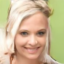

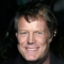

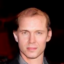

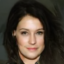

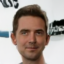

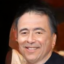

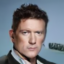

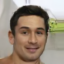

In [9]:
# Inspect counts and report values for Q4c.
import json
from pathlib import Path
from IPython.display import Image, display

KID_ROOT = Path("/content/kid_eval")
GENERATED_DIR = KID_ROOT / "generated_1k"
REAL_DIR = KID_ROOT / "real_1k"
METRICS_OUTPUT = KID_ROOT / "kid_metrics.json"

print("Generated PNG count:")
!find "{GENERATED_DIR}" -type f -name "*.png" | wc -l
print("Real PNG count:")
!find "{REAL_DIR}" -type f -name "*.png" | wc -l

metrics = json.loads(Path(METRICS_OUTPUT).read_text())
print(metrics)
print("KID mean:", metrics["kernel_inception_distance_mean"])
print("KID std:", metrics["kernel_inception_distance_std"])

preview_files = sorted(Path(GENERATED_DIR).glob("*.png"))[:8]
for preview_file in preview_files:
    display(Image(filename=str(preview_file), width=96))
